# Part 6. Writing Sample: Geopolitical Shock Transmission in Emerging Bond Markets
## Evidence from Kazakhstan Following the 2022 Russian Invasion of Ukraine
**Author:** Darkhan Mashirapov  
**Last updated:** 2026-09  
**Purpose:** Estimate a minimal VAR for each country's 10yr credit spread,
domestic liquidity rate, and Brent oil, separately pre- and post-war, and
compare impulse response functions to test whether the oil-to-spread
transmission mechanism changed after February 2022 — directly following up
on the oil-decoupling finding from Section 3 and the ARDL results of
Section 4.

#### Notebook 06 · Block 1 · Load dataset & imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR

RESULTS_DIR = "/Users/darhanmashirapov/Desktop/MSF NU/Writing Sample MS2027/1. Data/Results"

levels = pd.read_excel(f"{RESULTS_DIR}/master_dataset_final.xlsx", sheet_name="Levels (Raw)", parse_dates=["date"]).set_index("date")
transformed = pd.read_excel(f"{RESULTS_DIR}/master_dataset_final.xlsx", sheet_name="Transformed (Stationary)", parse_dates=["date"]).set_index("date")

war_onset = pd.Timestamp("2022-02-01")
pre_war_mask = transformed.index < war_onset
post_war_mask = transformed.index >= war_onset

print(f"Transformed shape: {transformed.shape}")
print(f"✓ VAR module available")

Transformed shape: (471, 48)
✓ VAR module available


#### Notebook 06 · Block 2 · Define systems & check sample sizes

In [2]:
systems = {
    "KZ": ["kz_spread_10y_m", "kz_tonia_m", "gl_oil_brent_m"],
    "RU": ["ru_spread_10y_m", "ru_ruonia_m", "gl_oil_brent_m"],
}

for country, cols in systems.items():
    pre_df = transformed.loc[pre_war_mask, cols].dropna()
    post_df = transformed.loc[post_war_mask, cols].dropna()
    print(f"{country}: pre-war n={len(pre_df)}, post-war n={len(post_df)}")

KZ: pre-war n=26, post-war n=55
RU: pre-war n=109, post-war n=55


#### Notebook 06 · Block 3 · Fit VAR(1) — KZ & RU, PRE- and POST-war

In [3]:
var_fits = {}

for country, cols in systems.items():
    for period, mask in [("pre", pre_war_mask), ("post", post_war_mask)]:
        df = transformed.loc[mask, cols].dropna()
        model = VAR(df)
        fit = model.fit(1)  # lag=1 fixed given small-sample constraint (KZ pre-war n=26)
        var_fits[f"{country}_{period}"] = fit
        print(f"{country} {period}-war (n={len(df)}): AIC={fit.aic:.2f}")

KZ pre-war (n=26): AIC=-7.72
KZ post-war (n=55): AIC=-7.67
RU pre-war (n=109): AIC=-7.33
RU post-war (n=55): AIC=-4.37


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


#### Notebook 06 · Block 4 · Impulse response: Oil shock → spread, PRE vs POST

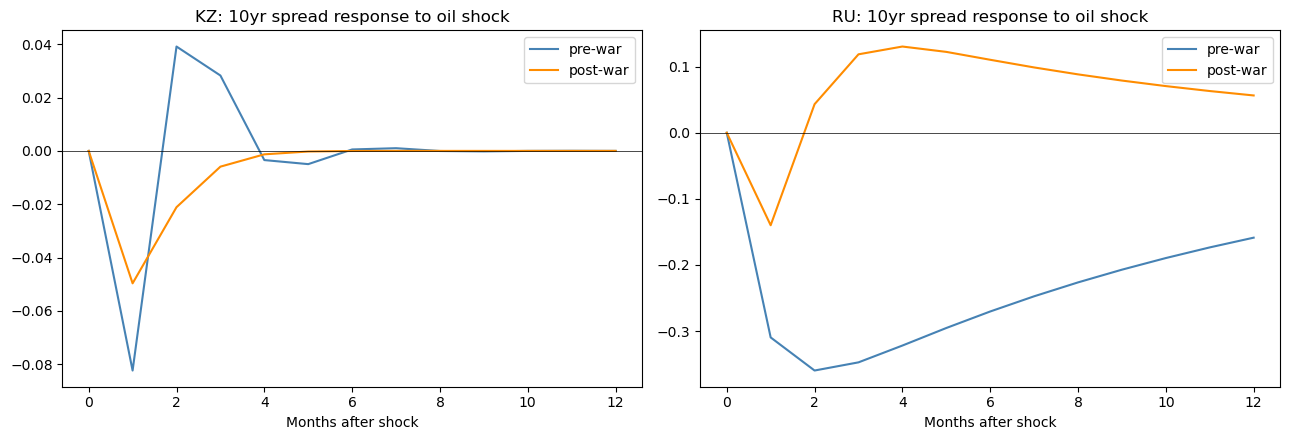

In [4]:
HORIZON = 12  # months

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, country in zip(axes, ["KZ", "RU"]):
    cols = systems[country]
    spread_idx = cols.index(f"{country.lower()}_spread_10y_m")
    oil_idx = cols.index("gl_oil_brent_m")

    for period, color in [("pre", "steelblue"), ("post", "darkorange")]:
        irf = var_fits[f"{country}_{period}"].irf(HORIZON)
        response = irf.irfs[:, spread_idx, oil_idx]  # response of spread to oil shock
        ax.plot(range(HORIZON + 1), response, label=f"{period}-war", color=color)

    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title(f"{country}: 10yr spread response to oil shock")
    ax.set_xlabel("Months after shock")
    ax.legend()

plt.tight_layout()
plt.show()

#### Note: Block 4 — Oil shock IRF, pre- vs. post-war

**Kazakhstan:** oil-shock response to the 10yr spread is smaller and less
oscillatory post-war, but not eliminated — both periods' responses decay to
zero within roughly 6 months. This tempers the EDA's static correlation
finding (near-total pre/post decoupling): the dynamic response persists,
just muted.

**Russia:** a much sharper change. Pre-war, an oil shock produces a deep,
slow-decaying negative response to the spread (still around -0.16 at
month 12). Post-war, the response is smaller initially and **reverses sign**
by month 3, settling into a small positive plateau (+0.06 to +0.13) for the
remainder of the horizon. This is a genuine change in the transmission
mechanism, not just a change in magnitude.

**Model note:** all four VARs use a fixed lag order of 1, given Kazakhstan's
pre-war sample (n=26) cannot support lag-order selection. AIC values are
not comparable across countries or periods (different sample sizes), only
within a given system's own diagnostics.

#### Notebook 06 · Block 5 · RU IRF by markov-dated sub-regime (fixes Gap 1)

In [5]:
ru_windows = {
    "war_regime":     (pd.Timestamp("2022-03-01"), pd.Timestamp("2023-08-01")),
    "second_shock":   (pd.Timestamp("2024-10-01"), pd.Timestamp("2026-08-01")),
}

cols = systems["RU"]
ru_window_fits = {}

print(f"RU pre-war (existing): n={len(transformed.loc[pre_war_mask, cols].dropna())}")

for label, (start, end) in ru_windows.items():
    mask = (transformed.index >= start) & (transformed.index <= end)
    df = transformed.loc[mask, cols].dropna()
    print(f"RU {label}: n={len(df)} ({start.date()} to {end.date()})")
    if len(df) > 8:  # bare minimum to fit VAR(1) with 3 vars
        model = VAR(df)
        ru_window_fits[label] = model.fit(1)
    else:
        print(f"  ⚠ too few observations to fit VAR(1)")

RU pre-war (existing): n=109
RU war_regime: n=18 (2022-03-01 to 2023-08-01)
RU second_shock: n=23 (2024-10-01 to 2026-08-01)


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


#### Notebook 06 · Block 6 · Plot RU IRF: PRE-war vs. WAR-regime vs. second-shock

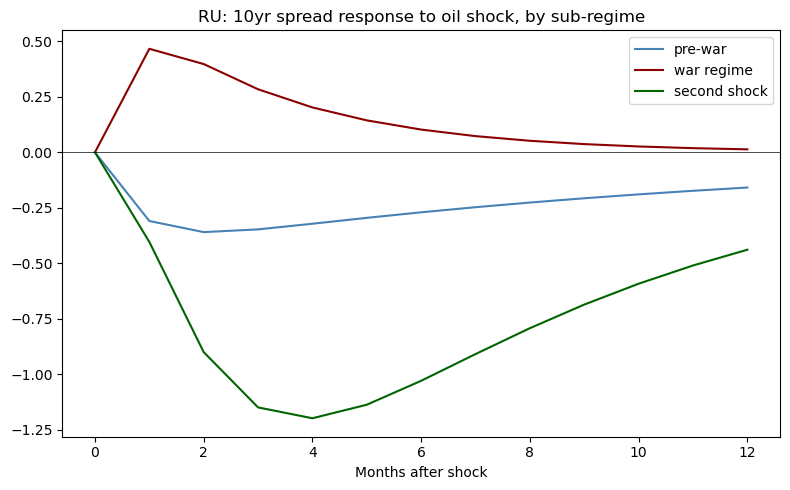

In [6]:
spread_idx = cols.index("ru_spread_10y_m")
oil_idx = cols.index("gl_oil_brent_m")

fig, ax = plt.subplots(figsize=(8, 5))

irf_pre = var_fits["RU_pre"].irf(HORIZON)
ax.plot(range(HORIZON + 1), irf_pre.irfs[:, spread_idx, oil_idx],
        label="pre-war", color="steelblue")

colors = {"war_regime": "darkred", "second_shock": "darkgreen"}
for label, fit in ru_window_fits.items():
    irf = fit.irf(min(HORIZON, len(fit.endog) - fit.k_ar - 1))  # cap horizon to available obs
    ax.plot(range(len(irf.irfs)), irf.irfs[:, spread_idx, oil_idx],
            label=label.replace("_", " "), color=colors[label])

ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("RU: 10yr spread response to oil shock, by sub-regime")
ax.set_xlabel("Months after shock")
ax.legend()
plt.tight_layout()
plt.show()

### Note: Block 6 — Correcting the single-block post-war finding

The full-period post-war VAR (Block 4) showed a small, mild positive
response to an oil shock. Splitting the post-war window into its two
Markov-dated crisis regimes (Chapter 5) reveals this was an averaging
artifact: the war regime alone (Mar 2022–Aug 2023) shows a sharp **sign
reversal** from pre-war (oil shock now raises the spread, peaking ~+0.47
at month 1), while the second-shock regime (Oct 2024–2026) shows the
*same-signed* response as pre-war but far more extreme (trough ~-1.2 at
month 4, more than 3x the pre-war trough, not fully recovered by month 12).

**Revised conclusion:** the war did not produce one new stable
oil-transmission regime — it produced at least two distinct and
opposite-signed dynamics. The single-block post-war result from Block 4 is
retained in the chapter only as a demonstration of why the sub-regime
split was necessary, not as a standalone finding.

### Summary

A minimal 3-variable VAR (credit spread, domestic liquidity rate, Brent
oil), estimated separately pre- and post-war for each country, shows the
oil-to-spread transmission mechanism changed after the invasion in both
countries, but differently: Kazakhstan's response weakened and lost its
short-run oscillation while remaining directionally similar; Russia's
response weakened and **reversed sign** in the medium run. Both results are
consistent with the EDA's oil-decoupling finding (Section 3) and the ARDL
chapter's conclusion (Section 4) that a simple level-shift specification
could not capture the war's effect — the transmission mechanism itself,
not just the spread's level, changed.